# Predicting Hotel Booking Cancellations


## 1. Setup

In [ ]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.compose import ColumnTransformer
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    balanced_accuracy_score, brier_score_loss, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve,
)from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, TargetEncoder
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="white", context="talk")
plt.rcParams["axes.grid"] = False
COLORS = {"navy": "#17324D", "teal": "#0E7C7B", "orange": "#F28E2B", "red": "#D1495B", "gray": "#6B7280"}
GREEN_CMAP = LinearSegmentedColormap.from_list("sea_to_dark_green", ["#2E8B57", "#013220"])

def green_shades(n):
    if n <= 1:
        return [GREEN_CMAP(0.85)]
    return [GREEN_CMAP(t) for t in np.linspace(0.08, 0.95, n)]


In [ ]:
try:
    import kagglehub
    _path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
    CSV_PATH = f"{_path}/hotel_bookings.csv"
except Exception:
    CSV_PATH = os.environ.get("HOTEL_BOOKINGS_CSV", "hotel_bookings.csv")
print("Loading dataset from:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
df.shape

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Loading dataset from: /kaggle/input/hotel-booking-demand/hotel_bookings.csv


(119390, 32)

## 2. Data Cleaning

In [ ]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" + df["arrival_date_month"] + "-" + df["arrival_date_day_of_month"].astype(str))
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
# children is only 0-filled here for the aggregate guest count -- the 'children'
# column itself keeps its NaNs so it can be median-imputed inside the pipeline (Table 3).
df["total_guests"] = df["adults"] + df["children"].fillna(0) + df["babies"]
df["arrival_day_of_week"] = df["arrival_date"].dt.day_name()
df["booked_value"] = df["adr"].clip(lower=0, upper=1000) * df["total_nights"]

In [ ]:
# Table 3 -- Principal data-quality findings and treatment
audit = pd.DataFrame({
    "Finding": ["Company missing", "Agent missing", "Country missing", "Children missing","Duplicate-looking rows", "Zero recorded guests", "Negative ADR", "ADR above EUR 1,000",],
    "Records": [
        int(df.company.isna().sum()),
        int(df.agent.isna().sum()),
        int(df.country.isna().sum()),
        int(df.children.isna().sum()),
        int(df.drop(columns=["arrival_date", "total_nights", "total_guests", "arrival_day_of_week", "booked_value"]).duplicated().sum()),
        int((df.total_guests == 0).sum()),
        int((df.adr < 0).sum()),
        int((df.adr > 1000).sum()),],
    "Treatment": [
        "Not applicable category", "Not applicable category", "Unknown / imputed in pipeline",
        "Median imputation in pipeline", "Retained; identity fields removed",
        "Excluded from modeling", "Excluded from modeling", "Excluded from modeling",],})
audit

,Finding,Records,Treatment
0,Company missing,112593,Not applicable category
1,Agent missing,16340,Not applicable category
2,Country missing,488,Unknown / imputed in pipeline
3,Children missing,4,Median imputation in pipeline
4,Duplicate-looking rows,31994,Retained; identity fields removed
5,Zero recorded guests,180,Excluded from modeling
6,Negative ADR,1,Excluded from modeling
7,"ADR above EUR 1,000",1,Excluded from modeling


In [ ]:
# Removed the two exclusion categories that affect row count (zero guests, ADR outliers).
# Duplicate-looking rows are RETAINED -- no unique booking ID exists in this anonymized
# data, so identical rows may be distinct bookings (e.g. group reservations).
clean = df[(df.total_guests > 0) & df.adr.between(0, 1000)].copy()
print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning:  {len(clean):,}  (matches report's 119,208)")

Rows before cleaning: 119,390
Rows after cleaning:  119,208  (matches report's 119,208)


In [ ]:
cancel_rate = clean.is_canceled.mean()
revenue_at_risk = clean.loc[clean.is_canceled == 1, "booked_value"].sum()
print(f"Overall cancellation rate: {cancel_rate:.1%}")
print(f"Booked room value attached to canceled reservations: EUR {revenue_at_risk:,.0f}")

Overall cancellation rate: 37.1%
Booked room value attached to canceled reservations: EUR 16,721,837


## 3. Exploratory Data Analysis

Each figure below is labeled to match its number in the report.

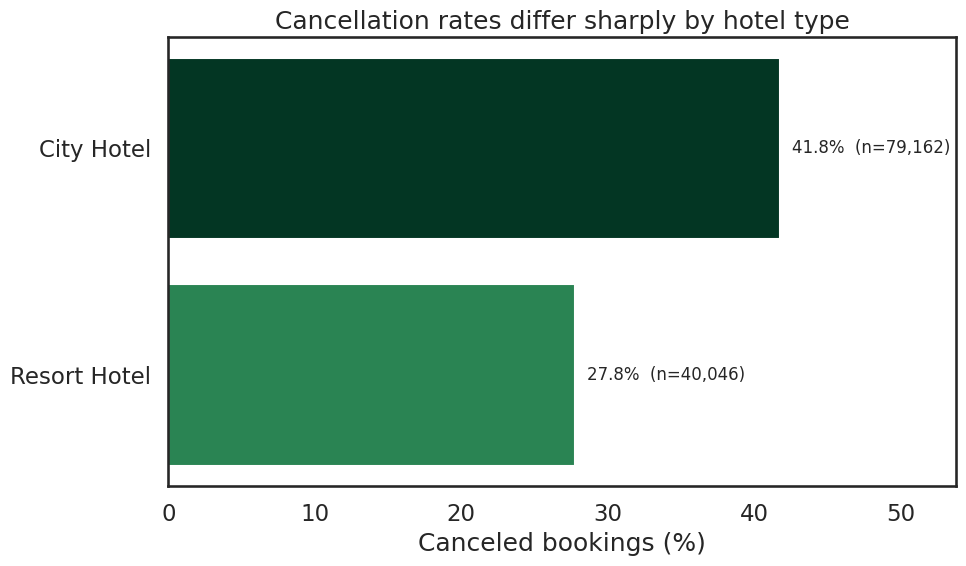

In [ ]:
# Figure 1 -- Cancellation rate by hotel type
by_hotel = clean.groupby("hotel")["is_canceled"].agg(["mean", "size"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(by_hotel.index, by_hotel["mean"] * 100, color=green_shades(len(by_hotel)))
ax.set(title="Cancellation rates differ sharply by hotel type", xlabel="Canceled bookings (%)", ylabel="")
max_val = (by_hotel["mean"] * 100).max()
ax.set_xlim(0, max_val + 12)  # headroom so the value labels never spill outside the axes
for bar, (_, row) in zip(bars, by_hotel.iterrows()):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2, f"{row['mean']:.1%}  (n={int(row['size']):,})", va="center", fontsize=12)
plt.tight_layout()
plt.show()


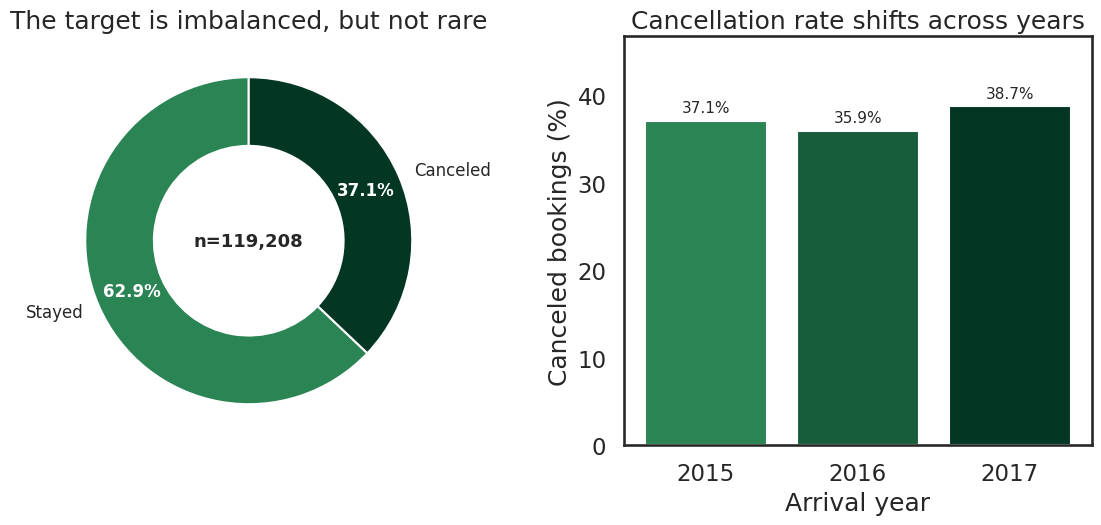

In [ ]:
# Figure 2 -- Target balance and cancellation drift across arrival years
yearly = clean.groupby("arrival_date_year").is_canceled.agg(["mean", "size"]).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.6))

# Stayed vs. Canceled is a part-of-whole split of every booking, so a donut communicates
# the composition more directly than a bar chart.
counts = clean.is_canceled.value_counts().sort_index()
wedges, _, autotexts = axes[0].pie( counts.values, labels=["Stayed", "Canceled"], colors=green_shades(len(counts)), autopct="%1.1f%%", pctdistance=0.78, startangle=90, wedgeprops=dict(width=0.42, edgecolor="white"), textprops={"fontsize": 12},)
for t in autotexts:
    t.set_color("white")
    t.set_fontweight("bold")
axes[0].set_title("The target is imbalanced, but not rare")
axes[0].text(0, 0, f"n={len(clean):,}", ha="center", va="center", fontsize=13, fontweight="bold")

# Arrival years are already in chronological order, so the color scale doubles as a timeline.
axes[1].bar(yearly.arrival_date_year.astype(str), yearly["mean"] * 100, color=green_shades(len(yearly)))
axes[1].set(title="Cancellation rate shifts across years", xlabel="Arrival year", ylabel="Canceled bookings (%)")
axes[1].set_ylim(0, (yearly["mean"] * 100).max() + 8)
for i, r in yearly.iterrows():
    axes[1].text(i, r["mean"] * 100 + 1, f"{r['mean']:.1%}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()


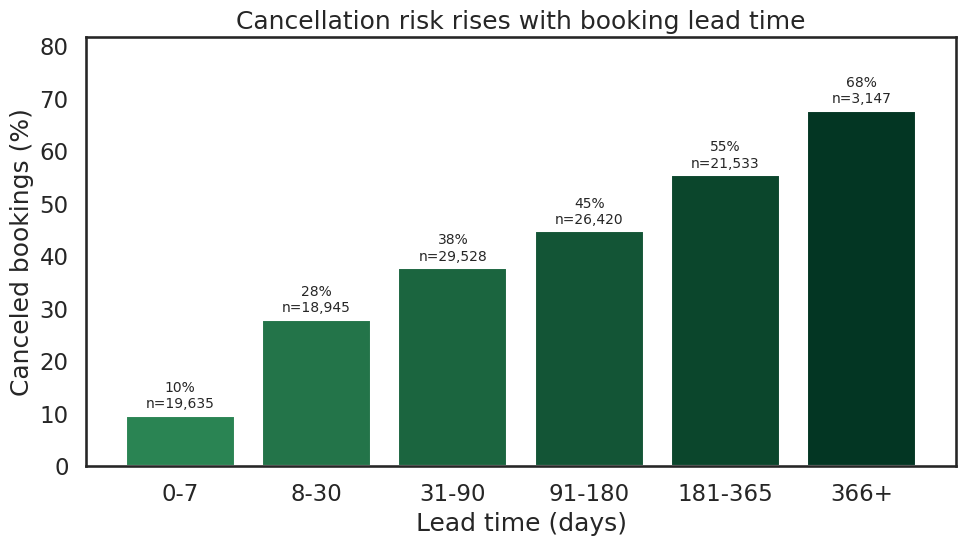

In [ ]:
# Figure 3 -- Cancellation rate by lead-time band
bins = [-1, 7, 30, 90, 180, 365, np.inf]
labels = ["0-7", "8-30", "31-90", "91-180", "181-365", "366+"]
clean["lead_time_band"] = pd.cut(clean.lead_time, bins=bins, labels=labels)
lead = clean.groupby("lead_time_band", observed=False).is_canceled.agg(["mean", "size"]).reset_index()
fig, ax = plt.subplots(figsize=(10, 5.8))
# Lead-time bands are ordered categories, not a continuous axis, so bars represent
# them more faithfully than an interpolated line.
ax.bar(lead.lead_time_band.astype(str), lead["mean"] * 100, color=green_shades(len(lead)))
ax.set(title="Cancellation risk rises with booking lead time", xlabel="Lead time (days)", ylabel="Canceled bookings (%)")
ax.set_ylim(0, (lead["mean"] * 100).max() + 14)  # room for the two-line labels above each bar
for i, r in lead.iterrows():
    ax.text(i, r["mean"] * 100 + 1.4, f"{r['mean']:.0%}\nn={int(r['size']):,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


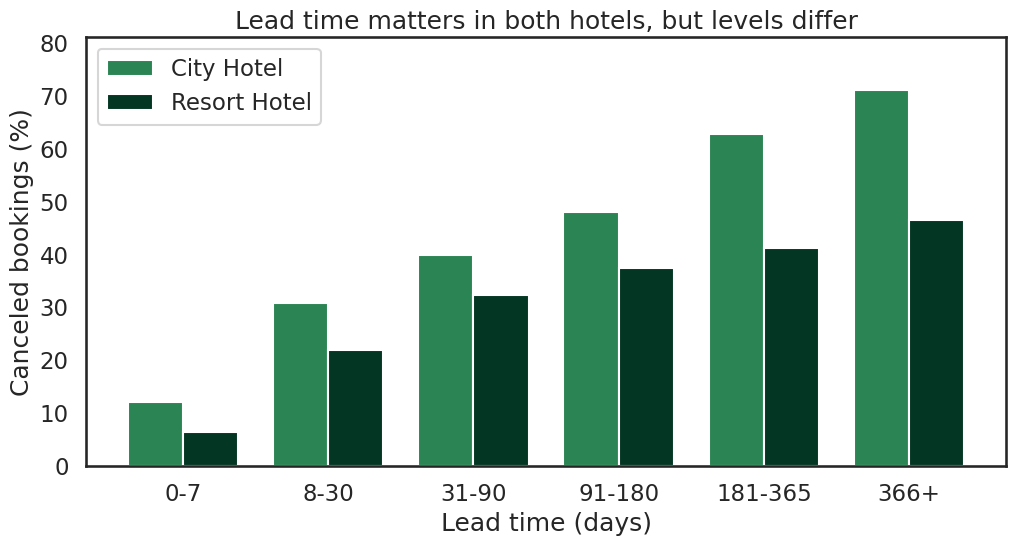

In [ ]:
# Figure 4 -- Lead-time relationship within each hotel
interaction = clean.pivot_table(index="lead_time_band", columns="hotel", values="is_canceled", aggfunc="mean", observed=False)
fig, ax = plt.subplots(figsize=(10.5, 5.8))
# Same ordered-bin x-axis as Figure 3, so grouped bars (not lines) are the appropriate type here too.
hotels = list(interaction.columns)
hotel_colors = green_shades(len(hotels))
x = np.arange(len(interaction.index))
width = 0.38
for offset, hotel, color in zip([-width / 2, width / 2], hotels, hotel_colors):
    ax.bar(x + offset, interaction[hotel] * 100, width=width, label=hotel, color=color)
ax.set(title="Lead time matters in both hotels, but levels differ", xlabel="Lead time (days)", ylabel="Canceled bookings (%)")
ax.set_xticks(x)
ax.set_xticklabels(interaction.index.astype(str))
ax.set_ylim(0, interaction.values.max() * 100 + 10)
ax.legend()
plt.tight_layout()
plt.show()


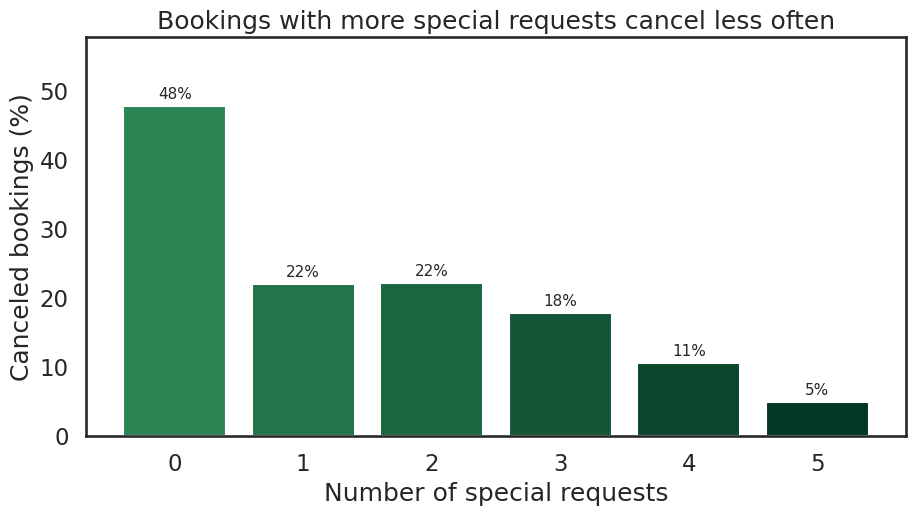

In [ ]:
# Figure 5 -- Cancellation rate by number of special requests
req = clean.groupby("total_of_special_requests").is_canceled.agg(["mean", "size"]).reset_index()
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.bar(req.total_of_special_requests.astype(str), req["mean"] * 100, color=green_shades(len(req)))
ax.set(title="Bookings with more special requests cancel less often", xlabel="Number of special requests", ylabel="Canceled bookings (%)")
ax.set_ylim(0, (req["mean"] * 100).max() + 10)
for i, r in req.iterrows():
    ax.text(i, r["mean"] * 100 + 1, f"{r['mean']:.0%}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()


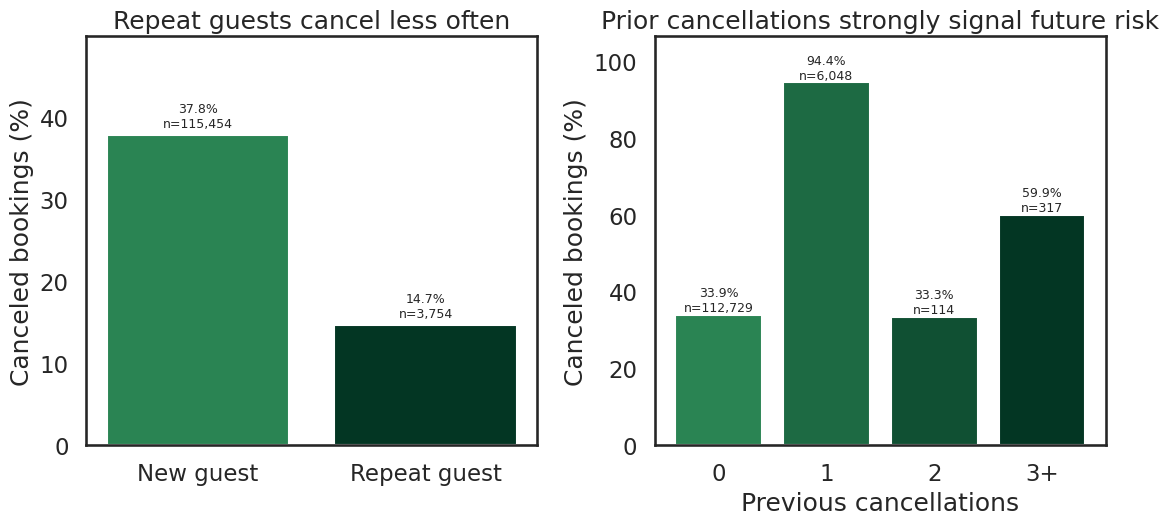

In [ ]:
# Figure 6 -- Repeat-guest and prior-cancellation patterns
clean["previous_cancellation_band"] = pd.cut(clean.previous_cancellations, bins=[-1, 0, 1, 2, np.inf], labels=["0", "1", "2", "3+"])
repeat = clean.groupby("is_repeated_guest").is_canceled.agg(["mean", "size"]).reset_index()
repeat["guest_type"] = repeat.is_repeated_guest.map({0: "New guest", 1: "Repeat guest"})
prior = clean.groupby("previous_cancellation_band", observed=False).is_canceled.agg(["mean", "size"]).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.6))
axes[0].bar(repeat.guest_type, repeat["mean"] * 100, color=green_shades(len(repeat)))
axes[0].set(title="Repeat guests cancel less often", ylabel="Canceled bookings (%)")
axes[0].set_ylim(0, (repeat["mean"] * 100).max() + 12)
axes[1].bar(prior.previous_cancellation_band.astype(str), prior["mean"] * 100, color=green_shades(len(prior)))
axes[1].set(title="Prior cancellations strongly signal future risk", xlabel="Previous cancellations", ylabel="Canceled bookings (%)")
axes[1].set_ylim(0, (prior["mean"] * 100).max() + 12)
for ax, data in [(axes[0], repeat), (axes[1], prior)]:
    for i, r in data.reset_index(drop=True).iterrows():
        ax.text(i, r["mean"] * 100 + 1, f"{r['mean']:.1%}\nn={int(r['size']):,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


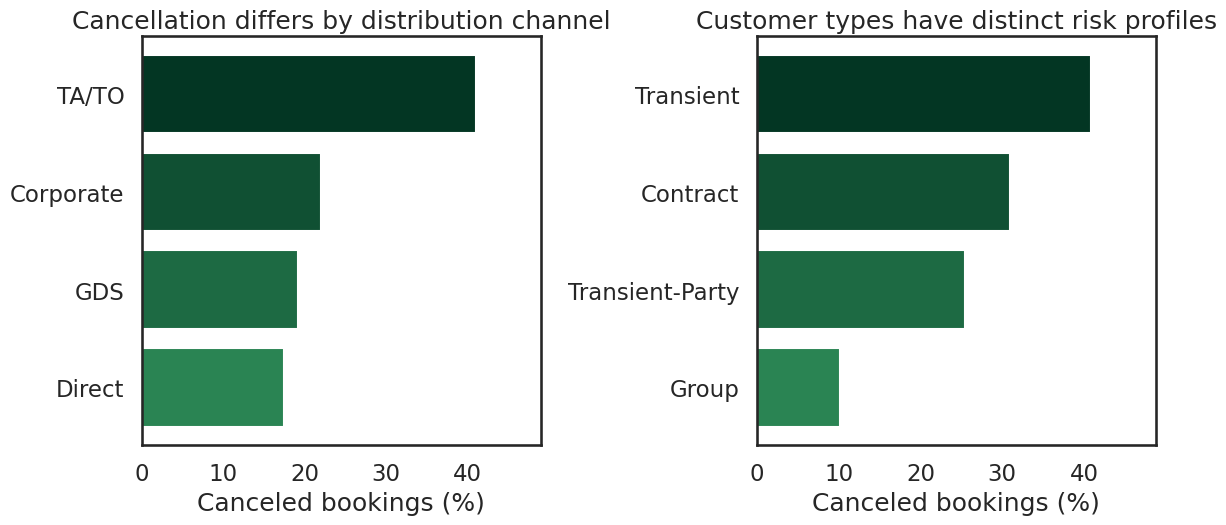

In [ ]:
# Figure 7 -- Distribution-channel and customer-type patterns
channel = clean.groupby("distribution_channel").is_canceled.agg(["mean", "size"]).query("size >= 100").sort_values("mean")
ctype = clean.groupby("customer_type").is_canceled.agg(["mean", "size"]).sort_values("mean")
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
axes[0].barh(channel.index, channel["mean"] * 100, color=green_shades(len(channel)))
axes[0].set(title="Cancellation differs by distribution channel", xlabel="Canceled bookings (%)", ylabel="")
axes[0].set_xlim(0, (channel["mean"] * 100).max() + 8)
axes[1].barh(ctype.index, ctype["mean"] * 100, color=green_shades(len(ctype)))
axes[1].set(title="Customer types have distinct risk profiles", xlabel="Canceled bookings (%)", ylabel="")
axes[1].set_xlim(0, (ctype["mean"] * 100).max() + 8)
plt.tight_layout()
plt.show()


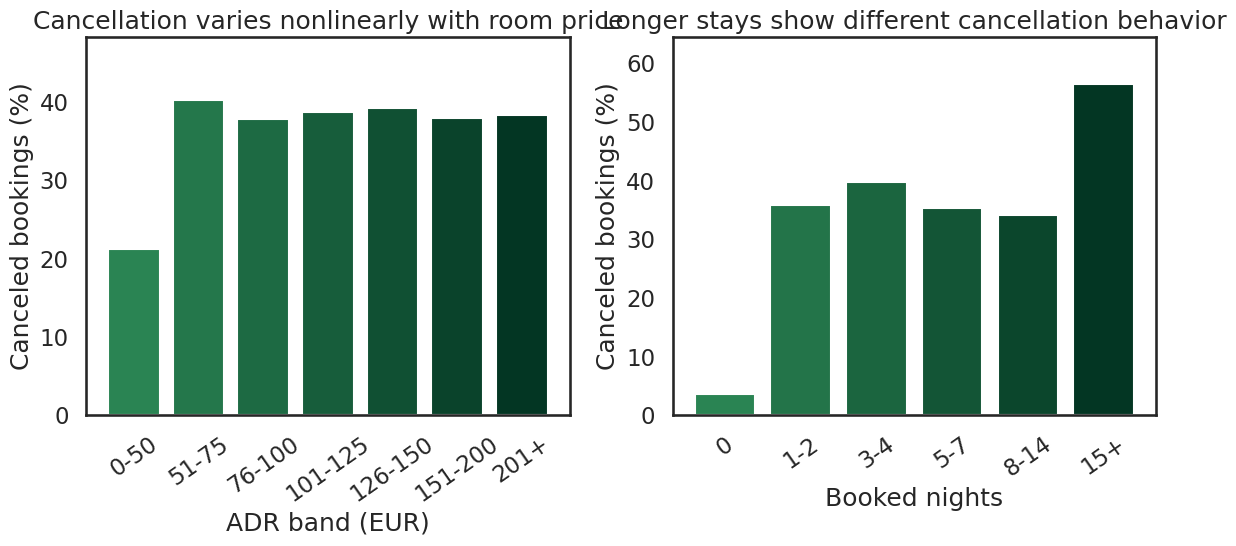

In [ ]:
# Figure 8 -- Cancellation patterns by ADR and booked nights
clean["adr_band"] = pd.cut(clean.adr, bins=[-0.01, 50, 75, 100, 125, 150, 200, np.inf], labels=["0-50", "51-75", "76-100", "101-125", "126-150", "151-200", "201+"])
clean["night_band"] = pd.cut(clean.total_nights, bins=[-1, 0, 2, 4, 7, 14, np.inf], labels=["0", "1-2", "3-4", "5-7", "8-14", "15+"])
adr = clean.groupby("adr_band", observed=False).is_canceled.agg(["mean", "size"]).reset_index()
nights = clean.groupby("night_band", observed=False).is_canceled.agg(["mean", "size"]).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 5.8))
# ADR and night bands are ordered categories, so bars represent them more
# appropriately than an interpolated line.
axes[0].bar(adr.adr_band.astype(str), adr["mean"] * 100, color=green_shades(len(adr)))
axes[0].set(title="Cancellation varies nonlinearly with room price", xlabel="ADR band (EUR)", ylabel="Canceled bookings (%)")
axes[0].set_ylim(0, (adr["mean"] * 100).max() + 8)
axes[0].tick_params(axis="x", rotation=35)
axes[1].bar(nights.night_band.astype(str), nights["mean"] * 100, color=green_shades(len(nights)))
axes[1].set(title="Longer stays show different cancellation behavior", xlabel="Booked nights", ylabel="Canceled bookings (%)")
axes[1].set_ylim(0, (nights["mean"] * 100).max() + 8)
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


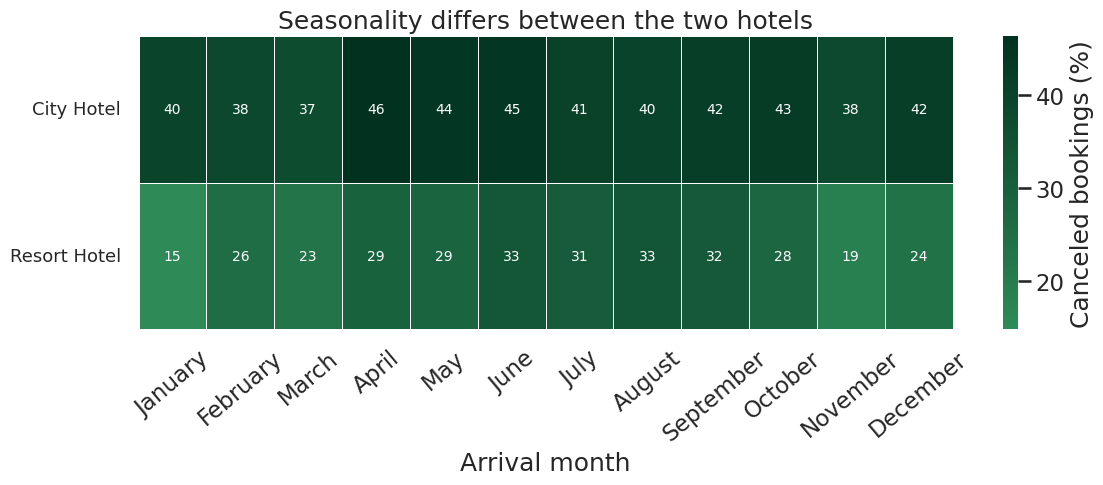

In [ ]:
# Figure 9 -- Hotel-specific seasonality
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
season = clean.pivot_table(index="hotel", columns="arrival_date_month", values="is_canceled", aggfunc="mean").reindex(columns=month_order)
fig, ax = plt.subplots(figsize=(12, 5.2))
sns.heatmap(
    season * 100, annot=True, fmt=".0f", cmap=GREEN_CMAP, cbar_kws={"label": "Canceled bookings (%)"},
    ax=ax, annot_kws={"fontsize": 10, "color": "white"}, linewidths=0.6, linecolor="white",
)
ax.set(title="Seasonality differs between the two hotels", xlabel="Arrival month", ylabel="")
ax.tick_params(axis="x", rotation=40)
ax.tick_params(axis="y", rotation=0, labelsize=13)
plt.tight_layout()
plt.show()


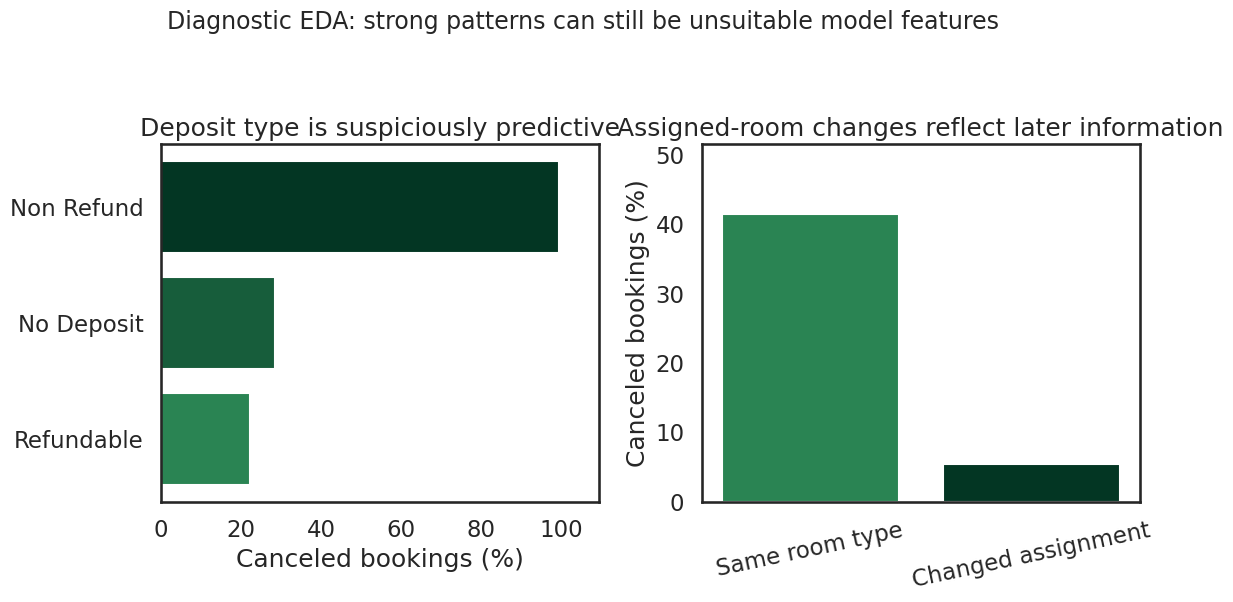

In [ ]:
# Figure 10 -- Diagnostic patterns excluded from the primary model
# deposit_type and assigned_room_type are shown here for diagnostic purposes only --
# both are excluded from the modeling feature set (see Section 4).
deposit = clean.groupby("deposit_type").is_canceled.agg(["mean", "size"]).sort_values("mean")
clean["room_changed"] = clean.assigned_room_type.ne(clean.reserved_room_type)
changed = clean.groupby("room_changed").is_canceled.agg(["mean", "size"]).reset_index()
changed["room_status"] = changed.room_changed.map({False: "Same room type", True: "Changed assignment"})
fig, axes = plt.subplots(1, 2, figsize=(12, 5.8))
axes[0].barh(deposit.index, deposit["mean"] * 100, color=green_shades(len(deposit)))
axes[0].set(title="Deposit type is suspiciously predictive", xlabel="Canceled bookings (%)", ylabel="")
axes[0].set_xlim(0, (deposit["mean"] * 100).max() + 10)
axes[1].bar(changed.room_status, changed["mean"] * 100, color=green_shades(len(changed)))
axes[1].set(title="Assigned-room changes reflect later information", ylabel="Canceled bookings (%)")
axes[1].set_ylim(0, (changed["mean"] * 100).max() + 10)
axes[1].tick_params(axis="x", rotation=12)
fig.suptitle("Diagnostic EDA: strong patterns can still be unsuitable model features", fontsize=17, y=1.05)
plt.tight_layout()
plt.show()


### Supplementary EDA (referenced in report text, not shown as a numbered figure)

The "Unusual results" paragraph in the report notes that no parking-request bookings were canceled. That claim isn't backed by a labeled figure in the current PDF -- this cell produces the supporting chart in case the group wants to add it.

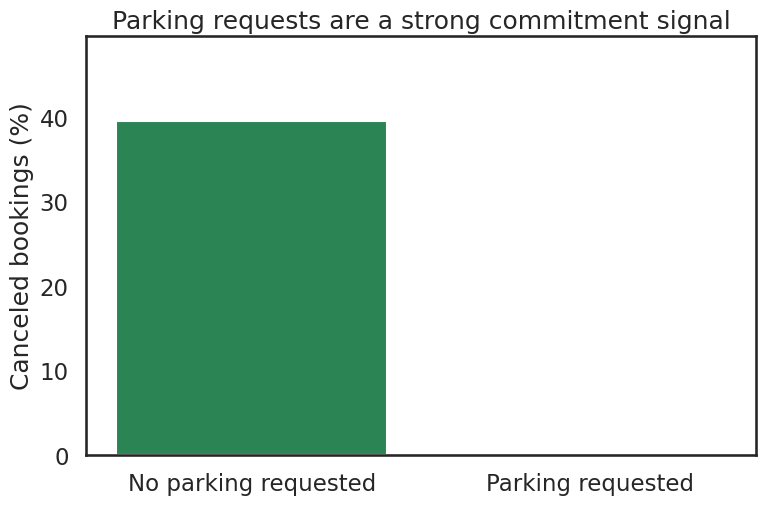

,needs_parking,mean,size,parking
0,False,0.395334,111799,No parking requested
1,True,0.000000,7409,Parking requested


In [ ]:
parking = clean.assign(needs_parking=clean.required_car_parking_spaces.gt(0)).groupby("needs_parking").is_canceled.agg(["mean", "size"]).reset_index()
parking["parking"] = parking.needs_parking.map({False: "No parking requested", True: "Parking requested"})
fig, ax = plt.subplots(figsize=(8, 5.4))
ax.bar(parking.parking, parking["mean"] * 100, color=green_shades(len(parking)))
ax.set(title="Parking requests are a strong commitment signal", ylabel="Canceled bookings (%)")
ax.set_ylim(0, (parking["mean"] * 100).max() + 10)
plt.tight_layout()
plt.show()
parking


## 4. Feature Set and Leakage Handling

Prediction point: **booking confirmation**. Fields that reveal the outcome directly or can change after booking are excluded, per the report's "Prediction point and leakage control" section.

In [ ]:
EXCLUDED_LEAKAGE = ["reservation_status", "reservation_status_date", "assigned_room_type", "booking_changes", "deposit_type"]

FEATURES = [
    "hotel", "lead_time", "arrival_date_month", "arrival_date_week_number", "arrival_date_day_of_month", "arrival_day_of_week",
    "stays_in_weekend_nights", "stays_in_week_nights", "total_nights", "adults", "children", "babies", "total_guests",
    "meal", "country", "market_segment", "distribution_channel", "is_repeated_guest", "previous_cancellations",
    "previous_bookings_not_canceled", "reserved_room_type", "agent", "company", "days_in_waiting_list", "customer_type", "adr",
    "required_car_parking_spaces", "total_of_special_requests",]
CATEGORICAL = ["hotel", "arrival_date_month", "arrival_day_of_week", "meal", "country", "market_segment",
               "distribution_channel", "reserved_room_type", "agent", "company", "customer_type"]
NUMERIC = [c for c in FEATURES if c not in CATEGORICAL]
print(f"Modeling on {len(FEATURES)} booking-time fields ({len(CATEGORICAL)} categorical, {len(NUMERIC)} numeric)")
print("Excluded as leakage risk:", EXCLUDED_LEAKAGE)

X = clean[FEATURES].copy()
y = clean["is_canceled"].astype(int)
# Country -> explicit "Unknown" category (Table 3 wording).
X["country"] = X["country"].astype("string").fillna("Unknown")
# Agent / company -> "Not applicable" category (Table 3 wording).
for col in ["agent", "company"]:
    X[col] = X[col].astype("string").fillna("Not applicable")
# Any other categorical column: consistent fallback fill.
for col in CATEGORICAL:
    X[col] = X[col].astype("string").fillna("Not applicable")
# children keeps its NaNs -- median-imputed inside the modeling pipeline below,
# fit on the training fold only, matching Table 3's "median imputation in pipeline".

Modeling on 28 booking-time fields (11 categorical, 17 numeric)
Excluded as leakage risk: ['reservation_status', 'reservation_status_date', 'assigned_room_type', 'booking_changes', 'deposit_type']


In [ ]:
train = clean.arrival_date_year.values == 2015
valid = clean.arrival_date_year.values == 2016
test = clean.arrival_date_year.values == 2017
train = pd.Series(train, index=clean.index)
valid = pd.Series(valid, index=clean.index)
test = pd.Series(test, index=clean.index)
print(f"Train (2015): {train.sum():,} | Validation (2016): {valid.sum():,} | Test (2017): {test.sum():,}")

Train (2015): 21,967 | Validation (2016): 56,622 | Test (2017): 40,619


## 5. Classification Models

Four candidates, compared on the 2016 validation split: a prior-probability baseline, regularized logistic regression, histogram gradient boosting, and random forest.

In [ ]:
def build_candidates(categorical, numeric):
    logistic = Pipeline([
        ("prep", ColumnTransformer([
            ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=25))]), categorical),
            ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", RobustScaler())]), numeric),])),
        ("model", LogisticRegression(max_iter=1200, C=.6, solver="liblinear")),])
    boosted = Pipeline([
        ("prep", ColumnTransformer([
            ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("target", TargetEncoder(target_type="binary", smooth="auto", random_state=42))]), categorical),
            ("num", SimpleImputer(strategy="median"), numeric),], verbose_feature_names_out=False)),
        ("model", HistGradientBoostingClassifier(max_iter=250, learning_rate=.07, max_leaf_nodes=20, min_samples_leaf=35, l2_regularization=1.0, random_state=42)),])
    forest = Pipeline([
        ("prep", ColumnTransformer([
            ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=25))]), categorical),
            ("num", SimpleImputer(strategy="median"), numeric),])),
        ("model", RandomForestClassifier(n_estimators=240, max_depth=18, min_samples_leaf=15, max_features="sqrt", class_weight="balanced_subsample", n_jobs=-1, random_state=42)),])
    dummy = DummyClassifier(strategy="prior")
    return {"Dummy baseline": dummy, "Logistic regression": logistic, "Gradient boosting": boosted, "Random forest": forest}

def metrics(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    return {"roc_auc": roc_auc_score(y_true, prob), "pr_auc": average_precision_score(y_true, prob), "accuracy": accuracy_score(y_true, pred), "balanced_accuracy": balanced_accuracy_score(y_true, pred), "precision": precision_score(y_true, pred, zero_division=0), "recall": recall_score(y_true, pred), "f1": f1_score(y_true, pred), "brier": brier_score_loss(y_true, prob),}

def ranking_metrics(y_true, prob, fraction=.20):
    n = max(1, int(len(y_true) * fraction))
    order = np.argsort(-prob)[:n]
    yy = np.asarray(y_true)[order]
    return float(yy.mean()), float(yy.sum() / np.asarray(y_true).sum())

In [ ]:
# Table 1 -- Model comparison on 2016 validation data
candidates = build_candidates(CATEGORICAL, NUMERIC)
fitted = {}
validation_rows = []
threshold = .5

for name, pipe in candidates.items():
    pipe.fit(X.loc[train], y.loc[train])
    prob = pipe.predict_proba(X.loc[valid])[:, 1]
    row = {"model": name, "threshold": threshold, **metrics(y.loc[valid], prob, threshold)}
    p20, c20 = ranking_metrics(y.loc[valid], prob)
    row.update({"precision_at_top_20pct": p20, "cancellations_captured_top_20pct": c20})
    validation_rows.append(row)
    fitted[name] = pipe

validation = pd.DataFrame(validation_rows).sort_values("pr_auc", ascending=False)
validation[["model", "roc_auc", "pr_auc", "accuracy", "precision", "recall"]].round(3)

,model,roc_auc,pr_auc,accuracy,precision,recall
1,Logistic regression,0.814,0.746,0.759,0.831,0.411
3,Random forest,0.779,0.740,0.777,0.840,0.468
2,Gradient boosting,0.799,0.716,0.733,0.832,0.322
0,Dummy baseline,0.500,0.359,0.641,0.000,0.000


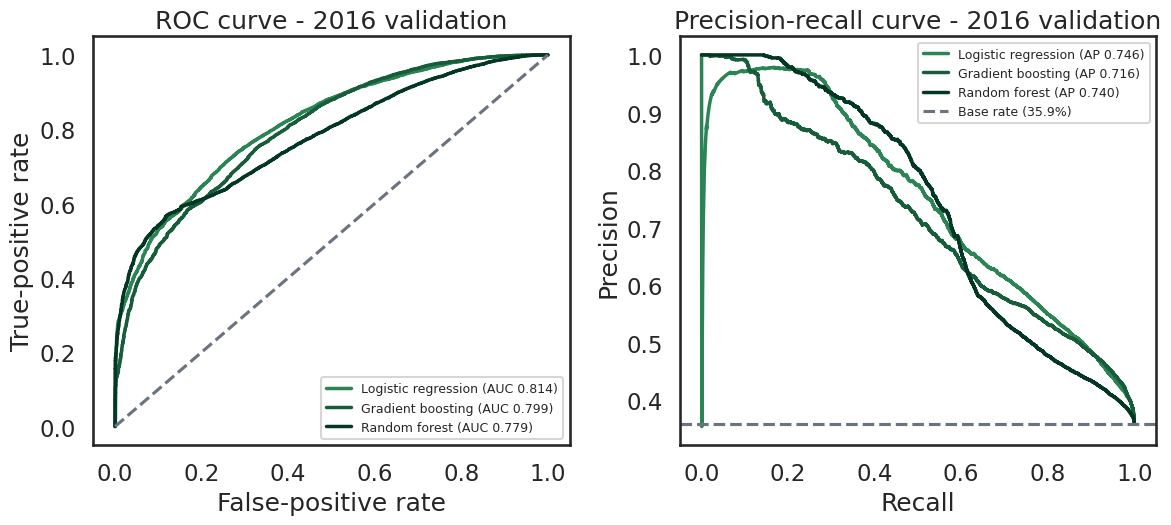

In [ ]:
# Figure 11 -- Validation ROC and precision-recall curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
model_names = ["Logistic regression", "Gradient boosting", "Random forest"]
model_colors = green_shades(len(model_names))
for name, color in zip(model_names, model_colors):
    pipe = fitted[name]
    prob = pipe.predict_proba(X.loc[valid])[:, 1]
    fpr, tpr, _ = roc_curve(y.loc[valid], prob)
    axes[0].plot(fpr, tpr, lw=2.5, label=f"{name} (AUC {roc_auc_score(y.loc[valid], prob):.3f})", color=color)
    prec, rec, _ = precision_recall_curve(y.loc[valid], prob)
    axes[1].plot(rec, prec, lw=2.5, label=f"{name} (AP {average_precision_score(y.loc[valid], prob):.3f})", color=color)
axes[0].plot([0, 1], [0, 1], ls="--", color=COLORS["gray"])
axes[0].set(title="ROC curve - 2016 validation", xlabel="False-positive rate", ylabel="True-positive rate")
axes[1].axhline(y.loc[valid].mean(), ls="--", color=COLORS["gray"], label=f"Base rate ({y.loc[valid].mean():.1%})")
axes[1].set(title="Precision-recall curve - 2016 validation", xlabel="Recall", ylabel="Precision")
axes[0].legend(fontsize=9, loc="lower right")
axes[1].legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()


In [ ]:
# Model selection rule: models within 0.005 PR-AUC of the best are a practical tie;
# the tied model with the higher ROC-AUC is selected.
best_pr_auc = validation.pr_auc.max()
eligible = validation.loc[validation.pr_auc >= best_pr_auc - .005].sort_values(["roc_auc", "pr_auc"], ascending=False)
winner = eligible.iloc[0].model
threshold = float(eligible.iloc[0].threshold)
print(f"Selected model: {winner} (threshold = {threshold})")

Selected model: Logistic regression (threshold = 0.5)


In [ ]:
# Refit the winner on 2015-2016 and evaluate once, untouched, on 2017.
final_pipe = candidates[winner]
final_pipe.fit(X.loc[train | valid], y.loc[train | valid])
test_prob = final_pipe.predict_proba(X.loc[test])[:, 1]

# Table 2 -- Final 2017 test metrics
test_metrics = metrics(y.loc[test], test_prob, threshold)
p20, c20 = ranking_metrics(y.loc[test], test_prob)
test_metrics.update({
    "precision_at_top_20pct": p20, "cancellations_captured_top_20pct": c20,
    "threshold": threshold, "model": winner, "n_test": int(test.sum()),
    "test_cancel_rate": float(y.loc[test].mean()),
})
pd.DataFrame([test_metrics]).round(3)

,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,brier,precision_at_top_20pct,cancellations_captured_top_20pct,threshold,model,n_test,test_cancel_rate
0,0.868,0.814,0.78,0.745,0.788,0.591,0.676,0.147,0.858,0.443,0.5,Logistic regression,40619,0.387


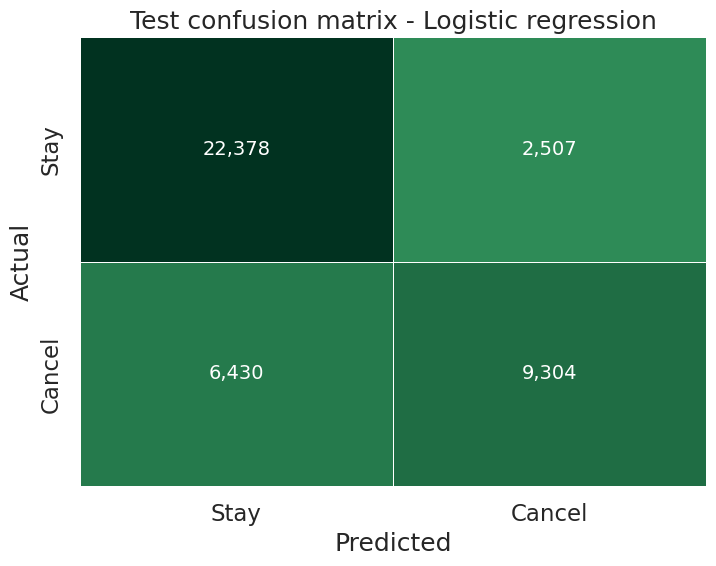

In [ ]:
# Figure 12 -- Test confusion matrix
test_pred = (test_prob >= threshold).astype(int)
cm = confusion_matrix(y.loc[test], test_pred)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    cm, annot=True, fmt=",", cmap=GREEN_CMAP, cbar=False, ax=ax,
    xticklabels=["Stay", "Cancel"], yticklabels=["Stay", "Cancel"],
    annot_kws={"fontsize": 14, "color": "white"}, linewidths=0.6, linecolor="white",
)
ax.set(title=f"Test confusion matrix - {winner}", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.show()


## 6. Interpretability and Robustness

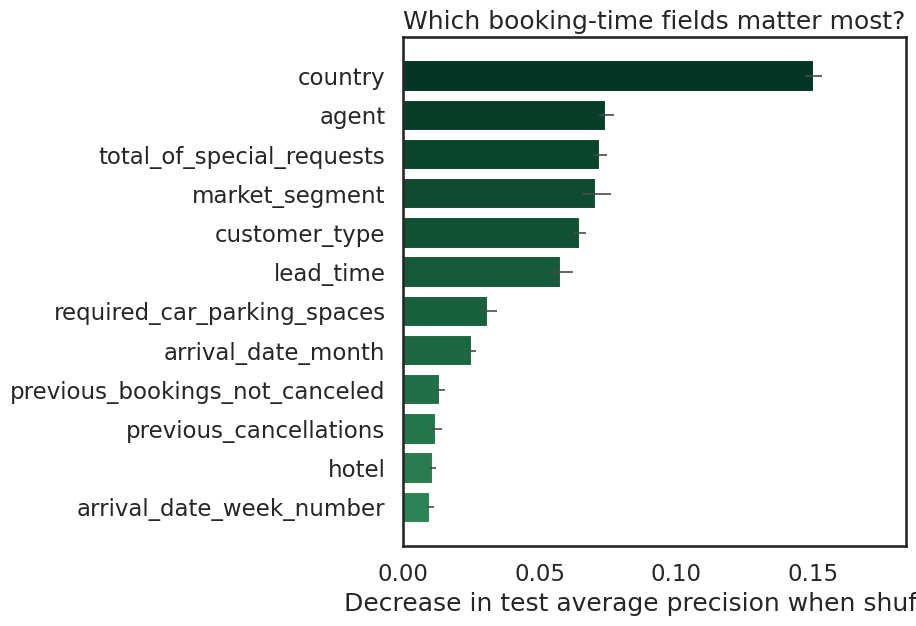

,feature,importance,std
14,country,0.150338,0.003064
21,agent,0.074458,0.002621
27,total_of_special_requests,0.072053,0.002653
15,market_segment,0.070777,0.005339
24,customer_type,0.064883,0.002225
1,lead_time,0.057875,0.004532
26,required_car_parking_spaces,0.031177,0.003131
2,arrival_date_month,0.025266,0.001560
19,previous_bookings_not_canceled,0.013640,0.001682
18,previous_cancellations,0.012223,0.001919


In [ ]:
# Figure 13 -- Model-agnostic permutation importance on a fixed 5,000-booking test sample
sample_idx = X.loc[test].sample(n=min(5000, int(test.sum())), random_state=42).index
perm = permutation_importance(final_pipe, X.loc[sample_idx], y.loc[sample_idx], n_repeats=4, random_state=42, scoring="average_precision", n_jobs=1)
imp = pd.DataFrame({"feature": X.columns, "importance": perm.importances_mean, "std": perm.importances_std}).sort_values("importance", ascending=False)
top = imp.head(12).sort_values("importance")
fig, ax = plt.subplots(figsize=(9.5, 6.6))
# Ranked ascending (top of the chart = most important), so intensity climbs with importance.
ax.barh(top.feature, top.importance, xerr=top["std"], color=green_shades(len(top)), error_kw={"ecolor": "#4A4A4A", "elinewidth": 1.2})
ax.set(title="Which booking-time fields matter most?", xlabel="Decrease in test average precision when shuffled", ylabel="")
ax.set_xlim(0, (top.importance + top["std"]).max() * 1.2)  # keeps error bars inside the axes
plt.tight_layout()
plt.show()
imp.head(12)


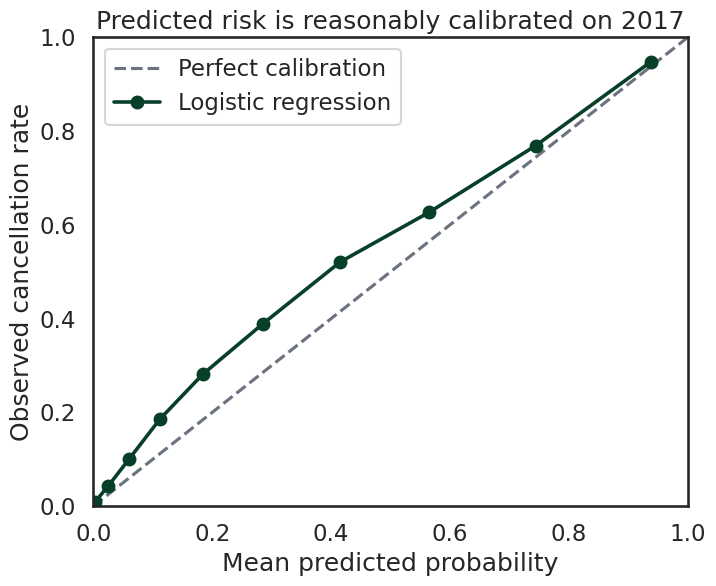

In [ ]:
# Figure 14 -- Calibration of predicted cancellation risk
frac_pos, mean_pred = calibration_curve(y.loc[test], test_prob, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.plot([0, 1], [0, 1], "--", color=COLORS["gray"], label="Perfect calibration")
ax.plot(mean_pred, frac_pos, marker="o", lw=2.6, color=green_shades(1)[0], label=winner)
ax.set(title="Predicted risk is reasonably calibrated on 2017", xlabel="Mean predicted probability", ylabel="Observed cancellation rate", xlim=(0, 1), ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()


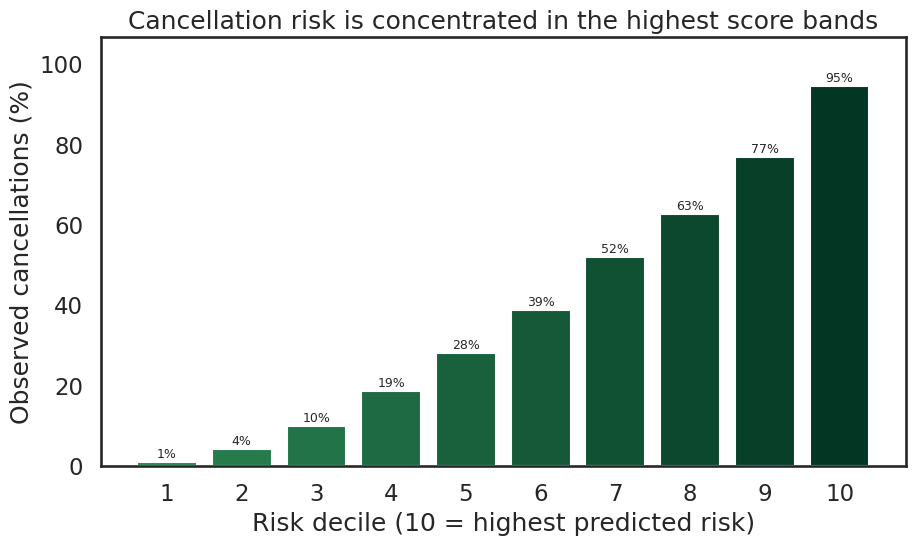

In [ ]:
# Figure 15 -- Observed cancellation by predicted-risk decile
risk = pd.DataFrame({"actual": np.asarray(y.loc[test]), "probability": test_prob})
risk["risk_decile"] = pd.qcut(risk.probability.rank(method="first"), 10, labels=range(1, 11))
deciles = risk.groupby("risk_decile", observed=False).agg(
    bookings=("actual", "size"), cancellations=("actual", "sum"),
    cancellation_rate=("actual", "mean"), mean_score=("probability", "mean"),
).reset_index()
deciles["share_of_all_cancellations"] = deciles.cancellations / deciles.cancellations.sum()
fig, ax = plt.subplots(figsize=(9.5, 5.8))
# Deciles are inherently ordered from lowest to highest predicted risk, so the color
# scale climbing alongside them is the natural (and literal) "chronological" mapping.
ax.bar(deciles.risk_decile.astype(str), deciles.cancellation_rate * 100, color=green_shades(len(deciles)))
ax.set(title="Cancellation risk is concentrated in the highest score bands", xlabel="Risk decile (10 = highest predicted risk)", ylabel="Observed cancellations (%)")
ax.set_ylim(0, (deciles.cancellation_rate * 100).max() + 12)
for i, r in deciles.iterrows():
    ax.text(i, r.cancellation_rate * 100 + 1, f"{r.cancellation_rate:.0%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


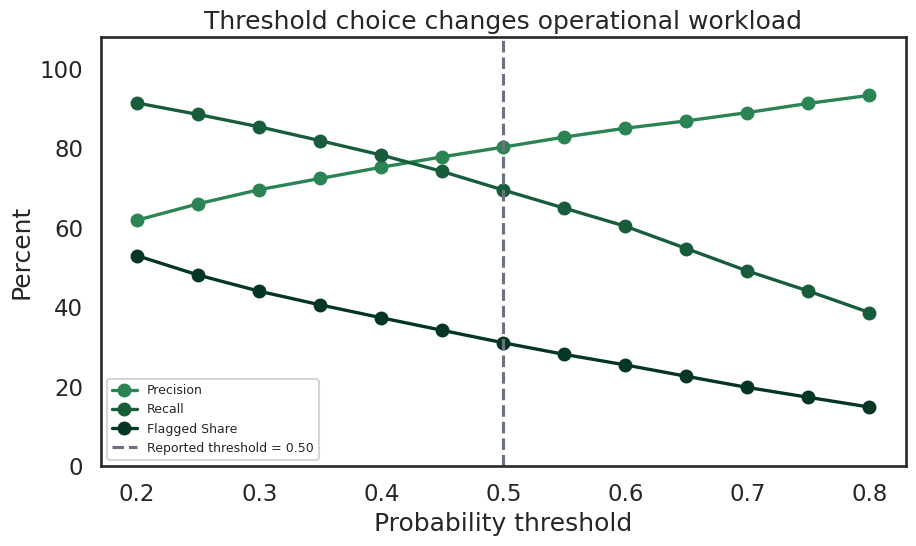

In [ ]:
# Figure 16 -- Validation threshold and workload trade-off
# Uses the validation-only fit of the winning model (not the 2015-2016 refit),
# evaluated on 2016, to avoid tuning against the test set.
valid_prob = fitted[winner].predict_proba(X.loc[valid])[:, 1]
threshold_rows = []
for t in np.arange(.20, .81, .05):
    pred = (valid_prob >= t).astype(int)
    threshold_rows.append({
        "threshold": round(float(t), 2),
        "precision": precision_score(y.loc[valid], pred, zero_division=0),
        "recall": recall_score(y.loc[valid], pred, zero_division=0),
        "flagged_share": float(pred.mean()),
    })
threshold_table = pd.DataFrame(threshold_rows)
fig, ax = plt.subplots(figsize=(9.5, 5.8))
metric_cols = ["precision", "recall", "flagged_share"]
metric_colors = green_shades(len(metric_cols))
for col, color in zip(metric_cols, metric_colors):
    ax.plot(threshold_table.threshold, threshold_table[col] * 100, marker="o", lw=2.4, label=col.replace("_", " ").title(), color=color)
ax.axvline(.50, ls="--", color=COLORS["gray"], label="Reported threshold = 0.50")
ax.set(title="Threshold choice changes operational workload", xlabel="Probability threshold", ylabel="Percent", ylim=(0, 108))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# Sensitivity check: does the result depend on coded commercial/geographic identifiers?
# Not used to select the winning model -- diagnostic only.
reduced_features = [c for c in X.columns if c not in {"country", "agent", "company"}]
reduced_cat = [c for c in CATEGORICAL if c in reduced_features]
reduced_num = [c for c in NUMERIC if c in reduced_features]
reduced = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=25))]), reduced_cat),
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", RobustScaler())]), reduced_num),
    ])),
    ("model", LogisticRegression(max_iter=1200, C=.6, solver="liblinear")),
])
reduced.fit(X.loc[train | valid, reduced_features], y.loc[train | valid])
reduced_prob = reduced.predict_proba(X.loc[test, reduced_features])[:, 1]

sensitivity = pd.DataFrame([
    {"feature_set": "Primary model", "roc_auc": test_metrics["roc_auc"], "pr_auc": test_metrics["pr_auc"], "brier": test_metrics["brier"]},
    {"feature_set": "Without country/agent/company", "roc_auc": roc_auc_score(y.loc[test], reduced_prob), "pr_auc": average_precision_score(y.loc[test], reduced_prob), "brier": brier_score_loss(y.loc[test], reduced_prob)},
])
sensitivity.round(3)

,feature_set,roc_auc,pr_auc,brier
0,Primary model,0.868,0.814,0.147
1,Without country/agent/company,0.799,0.741,0.174


## 7. Summary

In [ ]:
print(f"Selected model: {winner}")
print(f"Test ROC-AUC: {test_metrics['roc_auc']:.3f}  |  Test PR-AUC: {test_metrics['pr_auc']:.3f}")
print(f"Test accuracy: {test_metrics['accuracy']:.1%}  |  Precision: {test_metrics['precision']:.1%}  |  Recall: {test_metrics['recall']:.1%}  |  F1: {test_metrics['f1']:.3f}")
print(f"Top-20% precision: {test_metrics['precision_at_top_20pct']:.1%}")
print(f"Cancellations captured in top 20%: {test_metrics['cancellations_captured_top_20pct']:.1%}")

Selected model: Logistic regression
Test ROC-AUC: 0.868  |  Test PR-AUC: 0.814
Test accuracy: 78.0%  |  Precision: 78.8%  |  Recall: 59.1%  |  F1: 0.676
Top-20% precision: 85.8%
Cancellations captured in top 20%: 44.3%


**Recommended solution** (per the report's Section 4):
- Score confirmed bookings and review the highest-risk group within each arrival week or month.
- Use reminders, easy reconfirmation, and wait-list planning -- never cancel, reject, or penalize a guest because of a score.
- Track PR-AUC, calibration, alert precision, and capture rate by hotel and major segment each month.
- Test the outreach process against business-as-usual before making it part of normal operations.

**Limitations:** the data end in 2017, cover only two anonymous Portuguese hotels, and don't include booking IDs, cancellation reasons, or whether a canceled room was resold. A different hotel would need to revalidate the patterns before using this model.

### Visualizing 'Smarter Wait-lists' Recommendation

This chart shows how the actual cancellation rate and the average predicted cancellation risk vary by arrival week in the 2017 test data. This can help identify specific periods where proactive wait-list management or targeted overbooking strategies might be most effective.

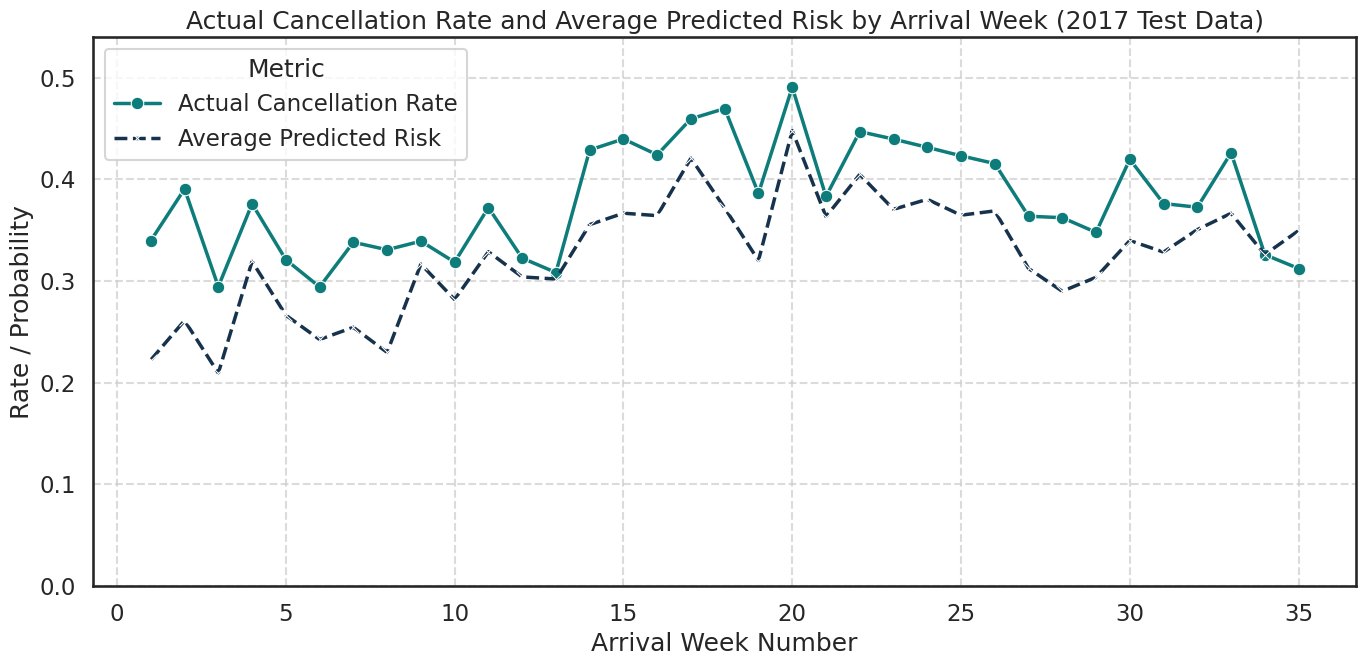

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine relevant test data into a single DataFrame
weekly_data = pd.DataFrame({
    'arrival_week': X.loc[test, 'arrival_date_week_number'],
    'actual_cancellation': y.loc[test],
    'predicted_probability': test_prob
})

# Group by arrival week to get actual cancellation rate and average predicted risk
weekly_summary = weekly_data.groupby('arrival_week').agg(
    actual_cancel_rate=('actual_cancellation', 'mean'),
    avg_predicted_risk=('predicted_probability', 'mean'),
    num_bookings=('actual_cancellation', 'size')
).reset_index()

# Plotting
fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(x='arrival_week', y='actual_cancel_rate', data=weekly_summary, label='Actual Cancellation Rate', marker='o', color=COLORS["teal"], linewidth=2.5)
sns.lineplot(x='arrival_week', y='avg_predicted_risk', data=weekly_summary, label='Average Predicted Risk', marker='x', linestyle='--', color=COLORS["navy"], linewidth=2.5)

ax.set(title='Actual Cancellation Rate and Average Predicted Risk by Arrival Week (2017 Test Data)',
       xlabel='Arrival Week Number',
       ylabel='Rate / Probability',
       ylim=(0, weekly_summary[['actual_cancel_rate', 'avg_predicted_risk']].max().max() * 1.1))

ax.legend(title='Metric')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()